# Purchasing Intention Classifier Development
The goal  of this classifier is to successfully predict if a user session will generate revenue. Two Decision Tree algorithms will be used for theis purpose: Random Forest and Adaptive Boosting.

## Libraries and Tools used
1. [Matplotlib ](https://matplotlib.org) - For plotting graphs.
0. [Numpy](https://numpy.org) - Calculations
0. [Pandas](https://pandas.pydata.org) - Dataframes and data manipulation
0. [Imbalanced-learn](https://imbalanced-learn.org/stable/) - Pipeline, SMOTE
0. [Scikit-learn](https://scikit-learn.org/stable/) - Data Analysis functions
0. [Jupyter](https://jupyter.org) - Notebook Tool

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

## Utilities
Additional functions to avoid repeating code.

In [ ]:
def adaboost_experiment(
    x_train: pd.DataFrame,
    x_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    param_grid: dict[list],
    *,
    use_scaler: bool = False,
    use_smote: bool = False,
    random_state: int = 37,
    scoring: str = 'recall',
) -> Pipeline:
    """Run adaptive boost algorithm pipeline with the ability to vary the SMOTE/Scaler.

    Args:
        x_train (pd.DataFrame): x training dataset.
        x_test (pd.DataFrame): x testing dataset.
        y_train (pd.Series): y training features.
        y_test (pd.Series): y testing features.
        param_grid (dict[list]): grid parameters.
        use_scaler (bool, optional): Use scaler. Defaults to False.
        use_smote (bool, optional): Use SMOTE. Defaults to False.
        random_state (int, optional): Random state for training. Defaults to 37.
        scoring (str, optional): Scoring methodology. Defaults to 'recall'.

    Returns:
        Pipeline: The finished model.

    """
    # Steps to be used in the pipeline, added conditionally based on the function argument
    steps = []

    # Add the scaler step if use_scaler is True.
    if use_scaler:
        steps.append(('scaler', StandardScaler()))

    # Add the SMOTE step if use_smote is True.
    if use_smote:
        steps.append(('smote', SMOTE(random_state=random_state)))

    # Finally, add the AdaBoostClassifier step.
    steps.append(('classification', AdaBoostClassifier(random_state=random_state)))

    # Create the pipeline and grid search objects.
    model = Pipeline(steps=steps)
    gs = GridSearchCV(
        estimator=model, param_grid=param_grid, scoring=scoring, cv=5, n_jobs=-1
    )

    # Fit the grid search object to the training data.
    gs.fit(x_train, y_train)

    # Print the results.
    print('=' * 60)
    print(f'Scaler: {use_scaler} | SMOTE: {use_smote}')
    print('Best Params:', gs.best_params_)
    print(f'Best {scoring}:', gs.best_score_)

    # Evaluate the best model on the test set.
    best_model = gs.best_estimator_
    y_pred = best_model.predict(x_test)

    # Print the confusion matrix and classification report.
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('Classification Report:')
    print(classification_report(y_test, y_pred, digits=3))

    # Return the best model.
    return best_model


def randomforest_experiment(
    x_train: pd.DataFrame,
    x_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    param_grid: dict[list],
    *,
    use_scaler: bool = False,
    use_smote: bool = False,
    random_state: int = 37,
    smote_k_neighbors: int | None = None,
    scoring: str = 'recall',
) -> Pipeline:
    """Create a Random Forest pipeline.

    Args:
      x_train (pd.DataFrame): x training dataset.
      x_test (pd.DataFrame): x testing dataset.
      y_train (pd.Series): y training features.
      y_test (pd.Series): y testing features.
      param_grid (dict[list]): grid parameters.
      use_scaler (bool, optional): Use scaler. Defaults to False.
      use_smote (bool, optional): Use SMOTE. Defaults to False.
      random_state (int, optional): Random state for training. Defaults to 37.
      smote_k_neighbors (int | None, optional): Number of neighbors. Defaults to None.
      scoring (str, optional): Scoring methodology. Defaults to 'recall'.

    Returns:
        Pipeline: Finished model pipeline.

    """
    # Steps to be used in the pipeline, added conditionally based on the function argument
    steps = []
    # Add the scaler step if use_scaler is True.
    if use_scaler:
        steps.append(('scaler', StandardScaler()))

    # Add the SMOTE step if use_smote is True.
    if use_smote:
        smote_kwargs = {'random_state': random_state}
        if smote_k_neighbors is not None:
            smote_kwargs['k_neighbors'] = smote_k_neighbors
        steps.append(('smote', SMOTE(**smote_kwargs)))

    # Finally, add the RandomForestClassifier step.
    steps.append(
        (
            'classification',
            RandomForestClassifier(
                criterion='entropy',
                max_features='sqrt',
                random_state=random_state,
                n_jobs=-1,
            ),
        )
    )

    # Fit the grid search object to the training data.
    model = Pipeline(steps=steps)

    # Create the pipeline and grid search objects.
    gs = GridSearchCV(
        estimator=model, param_grid=param_grid, scoring=scoring, cv=5, n_jobs=-1
    )
    gs.fit(x_train, y_train)

    # Print the results.
    print('=' * 60)
    print(f'Scaler: {use_scaler} | SMOTE: {use_smote}')
    print('Best Params:', gs.best_params_)
    print(f'Best {scoring}:', gs.best_score_)

    # Evaluate the best model on the test set.
    best_model = gs.best_estimator_
    y_pred = best_model.predict(x_test)

    # Print the confusion matrix and classification report.
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('Classification Report:')
    print(classification_report(y_test, y_pred, digits=3))

    return best_model

## Data Exploration

### Data Overview
Examine the different aspects of the data in order to develop a general insight into the data.

In [ ]:
# Importing dataset
dataset = pd.read_csv('online_shoppers_intention.csv')
dataset

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [ ]:
# View first 5 rows of the dataset
dataset.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
# View the number of rows and columns in the dataset.
dataset.shape


(12330, 18)

In [ ]:
# View the count and data type of each column in the dataset.
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
# View the statistical summary of the dataset.
dataset.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [ ]:
# Check for dataset balance. Target value is imbalanced.
print(dataset['Revenue'].value_counts(normalize=True))
print(dataset['Revenue'].value_counts())

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64
Revenue
False    10422
True      1908
Name: count, dtype: int64


In [ ]:
# View number of unique values in each column.
dataset.nunique().sort_values()

,0
Revenue,2
Weekend,2
VisitorType,3
SpecialDay,6
OperatingSystems,8
Region,9
Month,10
Browser,13
Informational,17
TrafficType,20


In [ ]:
# Examine data types to identify categorical and numerical features.
dataset.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


### Feature Influence
This is a preliminary step to understand the data and may inform feature selection.

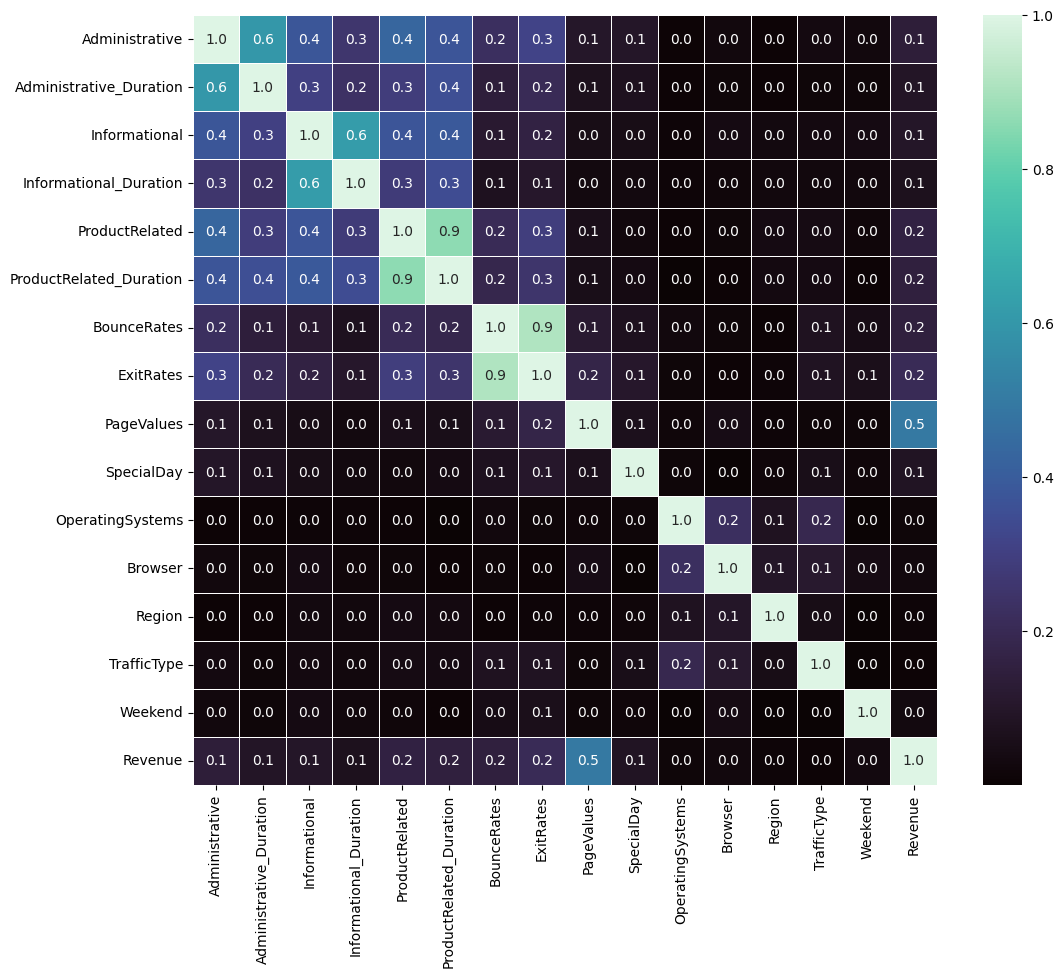

In [ ]:
# Examine correlation to see which features are most correlated with the target variable.
corr = dataset.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(
    np.abs(corr),
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cmap='mako',
)
plt.show()

In [ ]:
# PageValues correlates to revenue. People with high PageValues purchase more.
print(dataset.groupby('Revenue')['PageValues'].mean())
print(dataset.groupby('Revenue')['ProductRelated_Duration'].mean())

Revenue
False     1.975998
True     27.264518
Name: PageValues, dtype: float64
Revenue
False    1069.987809
True     1876.209615
Name: ProductRelated_Duration, dtype: float64


## Data Cleaning
Prepare the data for training


### Missing Values

In [ ]:
# No missing values in the dataset
dataset.isna().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


### Duplicates


In [ ]:
# Duplicates may be present
dups = dataset.duplicated()
dups.sum()

np.int64(125)

Check the proportion of True/False in the target variable, to confirm dropping duplicates does not meaningfully change the distribution of the target variable.

In [ ]:
# Examine proportion of dataset with duplicates against without duplicates.
dataset['Revenue'].mean(), dataset.drop_duplicates()['Revenue'].mean()

(np.float64(0.15474452554744525), np.float64(0.15632937320770177))

Many columns are precise, millisecond timestamps, with other specific identifiers, such as OS, browser, region and traffic type, so it is unlikely these are different.
They also all have Revenue = False, which is the majority class, so it is less likely to have an impact on the dataset.

In [ ]:
# Examine duplicates.
dataset[dataset.duplicated(keep=False)].head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
85,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
132,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


In [ ]:
# Check number of duplicates with Revenue = False
dup_false = dataset.loc[dups & (dataset['Revenue'] is False)]

print(len(dup_false))

0


In [ ]:
# Drop the duplicates.
dataset = dataset.drop_duplicates()

### Invalid Values
Confirm all values are within expected ranges.

In [ ]:
# Check for invalid values. Step recommended by ChatGPT
# Check for values below 0 and above 1.
print((dataset[['BounceRates', 'ExitRates', 'SpecialDay']] < 0).sum())
print((dataset[['BounceRates', 'ExitRates', 'SpecialDay']] > 1).sum())

print(
    (
        dataset[
            [
                'Administrative_Duration',
                'Informational_Duration',
                'ProductRelated_Duration',
            ]
        ]
        < 0
    ).sum()
)

BounceRates    0
ExitRates      0
SpecialDay     0
dtype: int64
BounceRates    0
ExitRates      0
SpecialDay     0
dtype: int64
Administrative_Duration    0
Informational_Duration     0
ProductRelated_Duration    0
dtype: int64


### Data Encoding
Converting data types so they are more appropriate for training.

Converting bools is not necessary, as this version of pandas one-hot encodes as bools rather than integers and scikit-learn can handle bools. I have chosen to encode the target as integers 1/0 as many ML pipelines expect or benefit from a clear 1/0 target and to maintain this consistency.


In [ ]:
# Converting target features into Binary feature.
dataset['Revenue'] = dataset['Revenue'].map({True: 1, False: 0})

/tmp/ipykernel_152/1740267070.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['Revenue'] = dataset['Revenue'].map({True: 1, False: 0})


#### Archived One-Hot Encoding and Results
Originally, I used one-hot encoding for the categorical features that were represented numerically. While this is not necessary for decision trees, it seemed a cleaner approach. However, it was found that using this method of encoding was less performant. The results of the one-hot encoding model are archived her for reference.

```python
# Convert categories into numerical features. Drop first used to reduce redundancy and
# correctly represent categorical values. Tree models may handle them as integers, but
# I chose to one-hot encode as they are not ordered values.
# Categorical values listed here: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset
final_data_ohe = pd.get_dummies(
    dataset,
    columns=[
        'Month',
        'VisitorType',
        'TrafficType',
        'Region',
        'Browser',
        'OperatingSystems',
    ],
    drop_first=True,
)
```

```python
{'balancing__k_neighbors': 7, 'classification__max_depth': 20, 'classification__n_estimators': 100}
0.7149152821865853
PageValues                 3.541132e-01
Administrative             8.205012e-02
ProductRelated_Duration    6.340157e-02
ExitRates                  5.432297e-02
ProductRelated             5.244022e-02
                               ...     
TrafficType_19             1.111232e-05
TrafficType_18             8.187449e-06
TrafficType_12             1.896036e-08
Browser_9                  0.000000e+00
TrafficType_17             0.000000e+00
Length: 68, dtype: float64
```

In [ ]:
# Converting categorical features into numerical features
dataset = pd.get_dummies(dataset, columns=['Month', 'VisitorType'], drop_first=True)

In [ ]:
final_data = dataset.copy()
final_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12205 non-null  int64  
 1   Administrative_Duration        12205 non-null  float64
 2   Informational                  12205 non-null  int64  
 3   Informational_Duration         12205 non-null  float64
 4   ProductRelated                 12205 non-null  int64  
 5   ProductRelated_Duration        12205 non-null  float64
 6   BounceRates                    12205 non-null  float64
 7   ExitRates                      12205 non-null  float64
 8   PageValues                     12205 non-null  float64
 9   SpecialDay                     12205 non-null  float64
 10  OperatingSystems               12205 non-null  int64  
 11  Browser                        12205 non-null  int64  
 12  Region                         12205 non-null  int6

In [ ]:
# View the first 5 rows of the final dataset.
final_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


In [ ]:
final_data.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


## Preparation for Model Development
The data was split into training and test data to ensure the model works well with unseen data.
SMOTE was utilised as the dataset is imbalanced and it could aid with improving Recall. Scaling was typically used with SMOTE. Tests were run without SMOTE for comparison.

### Train / Test Split

In [ ]:
# Remove Revenue from predictive values
x = final_data.drop('Revenue', axis=1)
y = final_data['Revenue']

# Verify shapes
print(f'Shape of X: {x.shape}')
print(f'Shape of y: {y.shape}')

Shape of X: (12205, 26)
Shape of y: (12205,)


In [ ]:
# Split the set into training and testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=37
)
# Ensure they produce similar values
print('Train positive rate:', y_train.mean())
print('Test positive rate:', y_test.mean())
print(x_train.shape, x_test.shape)

Train positive rate: 0.15628840639082342
Test positive rate: 0.15649324047521507
(9764, 26) (2441, 26)


### Random Forest Pipeline

#### Set up parameter grid for Random Forest


In [ ]:
# Random forest parameter grid for tuning, reduced to the best params for speed.
random_grid_param = {
    'classification__n_estimators': [10, 200],
    'classification__max_depth': [10],
    'classification__min_samples_leaf': [11],
    'classification__min_samples_split': [2],
    'smote__k_neighbors': [7, 10],  # Hyperparameter for SMOTE
}

# Full parameter set used is listed below. The below parameters ran fine for
# testing locally, but google colab takes too much time to use them.
"""
random_grid_param = {
    'classification__n_estimators': [10, 50, 100, 200],
    'classification__max_depth': [None, 10, 20],
    'classification__min_samples_leaf': [7, 9, 11],
    'classification__min_samples_split': [2, 3, 4],
    'smote__k_neighbors': [7, 8, 10, 12],  # Hyperparameter for SMOTE
}
"""

"\nrandom_grid_param = {\n    'classification__n_estimators': [10, 50, 100, 200],\n    'classification__max_depth': [None, 10, 20],\n    'classification__min_samples_leaf': [7, 9, 11],\n    'classification__min_samples_split': [2, 3, 4],\n    'smote__k_neighbors': [7, 8, 10, 12],  # Hyperparameter for SMOTE\n}\n"

#### Implement standard pipeline

##### Test with SMOTE and Scaler

In [ ]:
# Implementing Random Forest Classifier
# Tuning the random forest parameters 'n_estimators', 'max_depth'
# and implementing cross-validation using Grid Search
model = randomforest_experiment(
    x_train, x_test, y_train, y_test, random_grid_param, use_smote=True, use_scaler=True
)
model

Scaler: True | SMOTE: True
Best Params: {'classification__max_depth': 10, 'classification__min_samples_leaf': 11, 'classification__min_samples_split': 2, 'classification__n_estimators': 200, 'smote__k_neighbors': 10}
Best recall: 0.7890110361084325
Confusion Matrix:
[[1837  222]
 [  79  303]]
Classification Report:
              precision    recall  f1-score   support

           0      0.959     0.892     0.924      2059
           1      0.577     0.793     0.668       382

    accuracy                          0.877      2441
   macro avg      0.768     0.843     0.796      2441
weighted avg      0.899     0.877     0.884      2441



Pipeline(steps=[('scaler', StandardScaler()),
                ('smote', SMOTE(k_neighbors=10, random_state=37)),
                ('classification',
                 RandomForestClassifier(criterion='entropy', max_depth=10,
                                        min_samples_leaf=11, n_estimators=200,
                                        n_jobs=-1, random_state=37))])

#### Create Refined Pipeline based on Importances
Examine which features have the greatest importance and create a model that focuses only on those features to examine if the performance improves.

In [ ]:
# Feature importances
feat_imp = pd.Series(
    model.named_steps['classification'].feature_importances_, index=x_train.columns
).sort_values(ascending=False)  # Getting feature importances list for the best model

print(feat_imp.head(25))

PageValues                       0.513702
Administrative                   0.082476
ExitRates                        0.065133
Administrative_Duration          0.042656
ProductRelated_Duration          0.040549
TrafficType                      0.037410
Month_Nov                        0.037184
ProductRelated                   0.034354
OperatingSystems                 0.028014
BounceRates                      0.021528
Browser                          0.018352
Region                           0.016313
Month_May                        0.015010
VisitorType_Returning_Visitor    0.010562
Informational                    0.010501
Month_Mar                        0.008571
Informational_Duration           0.005133
SpecialDay                       0.003368
Weekend                          0.002726
Month_Dec                        0.002154
Month_Sep                        0.001957
Month_Oct                        0.001008
Month_Jul                        0.000962
Month_Feb                        0

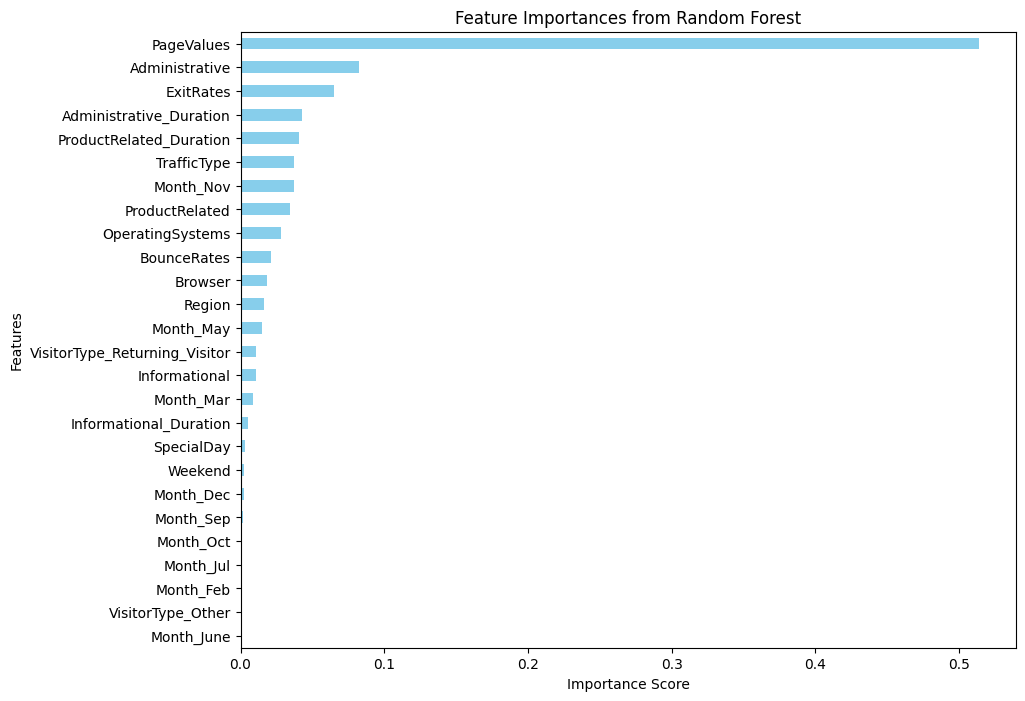

Number of features selected: 15
Selected Significant Features:
1. PageValues
2. Administrative
3. ExitRates
4. Administrative_Duration
5. ProductRelated_Duration
6. TrafficType
7. Month_Nov
8. ProductRelated
9. OperatingSystems
10. BounceRates
11. Browser
12. Region
13. Month_May
14. VisitorType_Returning_Visitor
15. Informational


In [ ]:
# Examine feat_imp and visualize for better threshold selection
plt.figure(figsize=(10, 8))
feat_imp.plot(kind='barh', color='skyblue')
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.show()

# Define a threshold or select top N features
# Given the drop after the first few features,
# we will select features with importance > 0.01
threshold = 0.01
selected_features = feat_imp[feat_imp > threshold].index.tolist()

# Create a list containing the names of these selected features
print(f'Number of features selected: {len(selected_features)}')

# Print the list of selected features
print('Selected Significant Features:')
for i, feature in enumerate(selected_features, 1):
    print(f'{i}. {feature}')

In [ ]:
# Filter original feature matrix x to include only selected features
X_refined = x[selected_features]

# Split refined data into training and testing sets
# Using a common random_state=37 and test_size=0.2 for consistency
x_train_ref, x_test_ref, y_train_ref, y_test_ref = train_test_split(
    X_refined, y, test_size=0.2, random_state=37, stratify=y
)

# Display shape and first few rows to verify
print(f'Shape of X_refined: {X_refined.shape}')
print('First 5 rows of X_refined:')
display(X_refined.head())

# Check the distribution to validate train and tst data.
print(f'Training set shape: {x_train_ref.shape}')
print(f'Testing set shape: {x_test_ref.shape}')
print('Train positive rate:', y_train_ref.mean())
print('Test positive rate:', y_test_ref.mean())

Shape of X_refined: (12205, 15)
First 5 rows of X_refined:


,PageValues,Administrative,ExitRates,Administrative_Duration,ProductRelated_Duration,TrafficType,Month_Nov,ProductRelated,OperatingSystems,BounceRates,Browser,Region,Month_May,VisitorType_Returning_Visitor,Informational
0,0.0,0,0.20,0.0,0.000000,1,False,1,1,0.20,1,1,False,True,0
1,0.0,0,0.10,0.0,64.000000,2,False,2,2,0.00,2,1,False,True,0
2,0.0,0,0.20,0.0,0.000000,3,False,1,4,0.20,1,9,False,True,0
3,0.0,0,0.14,0.0,2.666667,4,False,2,3,0.05,2,2,False,True,0
4,0.0,0,0.05,0.0,627.500000,4,False,10,3,0.02,3,1,False,True,0


Training set shape: (9764, 15)
Testing set shape: (2441, 15)
Train positive rate: 0.15628840639082342
Test positive rate: 0.15649324047521507


In [ ]:
best_rf_refined = randomforest_experiment(
    x_train_ref,
    x_test_ref,
    y_train_ref,
    y_test_ref,
    random_grid_param,
    use_scaler=True,
    use_smote=True,
)
best_rf_refined

Scaler: True | SMOTE: True
Best Params: {'classification__max_depth': 10, 'classification__min_samples_leaf': 11, 'classification__min_samples_split': 2, 'classification__n_estimators': 200, 'smote__k_neighbors': 7}
Best recall: 0.7922832958319941
Confusion Matrix:
[[1833  226]
 [  80  302]]
Classification Report:
              precision    recall  f1-score   support

           0      0.958     0.890     0.923      2059
           1      0.572     0.791     0.664       382

    accuracy                          0.875      2441
   macro avg      0.765     0.840     0.793      2441
weighted avg      0.898     0.875     0.882      2441



Pipeline(steps=[('scaler', StandardScaler()),
                ('smote', SMOTE(k_neighbors=7, random_state=37)),
                ('classification',
                 RandomForestClassifier(criterion='entropy', max_depth=10,
                                        min_samples_leaf=11, n_estimators=200,
                                        n_jobs=-1, random_state=37))])

#### Test without PageValues
PageValues is a highly influential feature to predicting Revenue, so we will examine model performance on removing the feature.

In [ ]:
# Create a feature matrix without 'PageValues'
x_no_pagevalues = x.drop(columns=['PageValues'])

# Split the data (without 'PageValues') into training and testing sets
x_train_npv, x_test_npv, y_train_npv, y_test_npv = train_test_split(
    x_no_pagevalues, y, test_size=0.2, random_state=37, stratify=y
)

print('x_no_pagevalues shape:', x_no_pagevalues.shape)
print('Train shape:', x_train_npv.shape, 'Test shape:', x_test_npv.shape)
print(
    'Train positive rate:', y_train_npv.mean(), 'Test positive rate:', y_test_npv.mean()
)

x_no_pagevalues shape: (12205, 25)
Train shape: (9764, 25) Test shape: (2441, 25)
Train positive rate: 0.15628840639082342 Test positive rate: 0.15649324047521507


In [ ]:
best_rf_npv = randomforest_experiment(
    x_train_npv,
    x_test_npv,
    y_train_npv,
    y_test_npv,
    random_grid_param,
    use_scaler=True,
    use_smote=True,
)

Scaler: True | SMOTE: True
Best Params: {'classification__max_depth': 10, 'classification__min_samples_leaf': 11, 'classification__min_samples_split': 2, 'classification__n_estimators': 200, 'smote__k_neighbors': 7}
Best recall: 0.5183306546662381
Confusion Matrix:
[[1615  444]
 [ 166  216]]
Classification Report:
              precision    recall  f1-score   support

           0      0.907     0.784     0.841      2059
           1      0.327     0.565     0.415       382

    accuracy                          0.750      2441
   macro avg      0.617     0.675     0.628      2441
weighted avg      0.816     0.750     0.774      2441



#### Test with only PageValues
PageValues is a highly important feature, so we will conduct an examination to see how much the other features contribute to the model.

In [ ]:
# Create a feature matrix with only 'PageValues'
x_only_pagevalues = x[['PageValues']]

# Split the data (with only 'PageValues') into training and testing sets
x_train_opv, x_test_opv, y_train_opv, y_test_opv = train_test_split(
    x_only_pagevalues, y, test_size=0.2, random_state=37, stratify=y
)

print(f'Shape of X_only_pagevalues: {x_only_pagevalues.shape}')
print(f'Training set shape (only PageValues): {x_train_opv.shape}')
print(f'Testing set shape (only PageValues): {x_test_opv.shape}')

Shape of X_only_pagevalues: (12205, 1)
Training set shape (only PageValues): (9764, 1)
Testing set shape (only PageValues): (2441, 1)


In [ ]:
best_rf_pv = randomforest_experiment(
    x_train_opv,
    x_test_opv,
    y_train_opv,
    y_test_opv,
    random_grid_param,
    use_scaler=True,
    use_smote=True,
)

Scaler: True | SMOTE: True
Best Params: {'classification__max_depth': 10, 'classification__min_samples_leaf': 11, 'classification__min_samples_split': 2, 'classification__n_estimators': 10, 'smote__k_neighbors': 7}
Best recall: 0.7968777456337727
Confusion Matrix:
[[1821  238]
 [  82  300]]
Classification Report:
              precision    recall  f1-score   support

           0      0.957     0.884     0.919      2059
           1      0.558     0.785     0.652       382

    accuracy                          0.869      2441
   macro avg      0.757     0.835     0.786      2441
weighted avg      0.894     0.869     0.877      2441



#### Test without SMOTE.
Running alternative methods to SMOTE. First, clean without, then using class weight balancing.

In [ ]:
param_grid_no_smote = {
    'n_estimators': [300],
    'max_depth': [5],
    'min_samples_leaf': [2],
    'min_samples_split': [2],
}

# Original Parameter Grid, above used for best paramters result
# to shorten training time in Colab.
""""
param_grid_no_smote = {
    'n_estimators': [200, 300, 400],
    'max_depth': [2, 5, 10],
    'min_samples_leaf': [2, 5, 7, 10],
    'min_samples_split': [2, 4],
}
"""

'"\nparam_grid_no_smote = {\n    \'n_estimators\': [200, 300, 400],\n    \'max_depth\': [2, 5, 10],\n    \'min_samples_leaf\': [2, 5, 7, 10],\n    \'min_samples_split\': [2, 4],\n}\n'

Archived Results of a test without SMOTE. Recall results were to low to be viable for use.

```python

randomforest_experiment(x_train, x_test, y_train, y_test, random_grid_param)

============================================================
Scaler: False | SMOTE: False
Best Params: {'classification__max_depth': None, 'classification__min_samples_leaf': 9, 'classification__min_samples_split': 2, 'classification__n_estimators': 10}
Best recall: 0.5760312868316726
Confusion Matrix:
[[1975   84]
 [ 159  223]]
Classification Report:
              precision    recall  f1-score   support

           0      0.925     0.959     0.942      2059
           1      0.726     0.584     0.647       382

    accuracy                          0.900      2441
   macro avg      0.826     0.771     0.795      2441
weighted avg      0.894     0.900     0.896      2441
```

#### Test with class weight balancing
Testing using class weight produced results more quickly and easily than testing variants with SMOTE. It was noticeably less resource intensive. It had higher recall but was slightly less performant for f1 scoring than our best Random Forest SMOTE model.

In [ ]:
# BModel with class weighting
rf_no_smote = RandomForestClassifier(
    criterion='entropy',
    max_features='sqrt',
    class_weight='balanced',
    random_state=37,
    n_jobs=-1,
)

# Grid search (recall as scoring, same as your best model)
gs = GridSearchCV(
    rf_no_smote, param_grid=param_grid_no_smote, scoring='recall', cv=5, n_jobs=-1
)

gs.fit(x_train, y_train)

print('=' * 60)
print('Class Weighting (No SMOTE)')
print('Best Params:', gs.best_params_)
print('Best Recall (CV):', gs.best_score_)

# Evaluate on test set
best_model = gs.best_estimator_
y_pred = best_model.predict(x_test)

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

print('Classification Report:')
print(classification_report(y_test, y_pred, digits=3))

Class Weighting (No SMOTE)
Best Params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best Recall (CV): 0.8394664095146256
Confusion Matrix:
[[1790  269]
 [  67  315]]
Classification Report:
              precision    recall  f1-score   support

           0      0.964     0.869     0.914      2059
           1      0.539     0.825     0.652       382

    accuracy                          0.862      2441
   macro avg      0.752     0.847     0.783      2441
weighted avg      0.897     0.862     0.873      2441



### Adaptive Boost Pipeline
Similar to the Random Forest Pipeline, the Adaptive Boost Pipeline will examine variable parameters, using SMOTE, the scaler, with and without PageValues.

#### Parameters for Adaptive Boost pipeline

In [ ]:
grid_param = {
    'classification__estimator': [
        DecisionTreeClassifier(max_depth=1, random_state=37),
        DecisionTreeClassifier(max_depth=2, random_state=37),
    ],
    'classification__n_estimators': [20, 100, 200],
    'classification__learning_rate': [0.005, 0.1, 0.3],
}

# Original Parameter Grid, above used for best paramters result
# to shorten training time in Colab.
"""
grid_param = {
    'classification__estimator': [
        DecisionTreeClassifier(max_depth=1, random_state=37),
        DecisionTreeClassifier(max_depth=2, random_state=37),
    ],
    'classification__n_estimators': [20, 50, 100, 200],
    'classification__learning_rate': [0.005, 0.01, 0.025, 0.05, 0.1, 0.3],
}
"""

"\ngrid_param = {\n    'classification__estimator': [\n        DecisionTreeClassifier(max_depth=1, random_state=37),\n        DecisionTreeClassifier(max_depth=2, random_state=37),\n    ],\n    'classification__n_estimators': [20, 50, 100, 200],\n    'classification__learning_rate': [0.005, 0.01, 0.025, 0.05, 0.1, 0.3],\n}\n"

#### Standard Pipeline
Tests variants between utilising the scaler and smote. The use of either resulted irrelevant as the PageValues feature had such a strong predictive importance that other variables were unimportant.

In [ ]:
adaboost_experiment(x_train, x_test, y_train, y_test, grid_param)

Scaler: False | SMOTE: False
Best Params: {'classification__estimator': DecisionTreeClassifier(max_depth=1, random_state=37), 'classification__learning_rate': 0.005, 'classification__n_estimators': 20}
Best recall: 0.8027686703096538
Confusion Matrix:
[[1819  240]
 [  77  305]]
Classification Report:
              precision    recall  f1-score   support

           0      0.959     0.883     0.920      2059
           1      0.560     0.798     0.658       382

    accuracy                          0.870      2441
   macro avg      0.760     0.841     0.789      2441
weighted avg      0.897     0.870     0.879      2441



Pipeline(steps=[('classification',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                                     random_state=37),
                                    learning_rate=0.005, n_estimators=20,
                                    random_state=37))])

In [ ]:
adaboost_experiment(x_train, x_test, y_train, y_test, grid_param, use_smote=True)

Scaler: False | SMOTE: True
Best Params: {'classification__estimator': DecisionTreeClassifier(max_depth=1, random_state=37), 'classification__learning_rate': 0.005, 'classification__n_estimators': 20}
Best recall: 0.8080145719489981
Confusion Matrix:
[[1819  240]
 [  77  305]]
Classification Report:
              precision    recall  f1-score   support

           0      0.959     0.883     0.920      2059
           1      0.560     0.798     0.658       382

    accuracy                          0.870      2441
   macro avg      0.760     0.841     0.789      2441
weighted avg      0.897     0.870     0.879      2441



Pipeline(steps=[('smote', SMOTE(random_state=37)),
                ('classification',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                                     random_state=37),
                                    learning_rate=0.005, n_estimators=20,
                                    random_state=37))])

In [ ]:
adaboost_experiment(x_train, x_test, y_train, y_test, grid_param, use_scaler=True)

Scaler: True | SMOTE: False
Best Params: {'classification__estimator': DecisionTreeClassifier(max_depth=1, random_state=37), 'classification__learning_rate': 0.005, 'classification__n_estimators': 20}
Best recall: 0.8027686703096538
Confusion Matrix:
[[1819  240]
 [  77  305]]
Classification Report:
              precision    recall  f1-score   support

           0      0.959     0.883     0.920      2059
           1      0.560     0.798     0.658       382

    accuracy                          0.870      2441
   macro avg      0.760     0.841     0.789      2441
weighted avg      0.897     0.870     0.879      2441



Pipeline(steps=[('scaler', StandardScaler()),
                ('classification',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                                     random_state=37),
                                    learning_rate=0.005, n_estimators=20,
                                    random_state=37))])

In [ ]:
best_ada_boost_model = adaboost_experiment(
    x_train, x_test, y_train, y_test, grid_param, use_smote=True, use_scaler=True
)

Scaler: True | SMOTE: True
Best Params: {'classification__estimator': DecisionTreeClassifier(max_depth=1, random_state=37), 'classification__learning_rate': 0.005, 'classification__n_estimators': 20}
Best recall: 0.8080145719489981
Confusion Matrix:
[[1819  240]
 [  77  305]]
Classification Report:
              precision    recall  f1-score   support

           0      0.959     0.883     0.920      2059
           1      0.560     0.798     0.658       382

    accuracy                          0.870      2441
   macro avg      0.760     0.841     0.789      2441
weighted avg      0.897     0.870     0.879      2441



#### Test Pagevalues removal
The removal of PageValues in some cases allowed greater recall but precision dropped to an unacceptable low level.
Removing SMOTE resulted in recall as low as 0.013.
Using f1 scoring improved precision, but lowered recall to an unacceptable low level.

In [ ]:
x_train_no_pv = x_train.drop(columns=['PageValues'])
x_test_no_pv = x_test.drop(columns=['PageValues'])

In [ ]:
adaboost_experiment(
    x_train_no_pv, x_test_no_pv, y_train, y_test, grid_param, use_smote=True
)

Scaler: False | SMOTE: True
Best Params: {'classification__estimator': DecisionTreeClassifier(max_depth=1, random_state=37), 'classification__learning_rate': 0.005, 'classification__n_estimators': 200}
Best recall: 0.887262402228651
Confusion Matrix:
[[ 870 1189]
 [  45  337]]
Classification Report:
              precision    recall  f1-score   support

           0      0.951     0.423     0.585      2059
           1      0.221     0.882     0.353       382

    accuracy                          0.494      2441
   macro avg      0.586     0.652     0.469      2441
weighted avg      0.837     0.494     0.549      2441



Pipeline(steps=[('smote', SMOTE(random_state=37)),
                ('classification',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                                     random_state=37),
                                    learning_rate=0.005, n_estimators=200,
                                    random_state=37))])

In [ ]:
adaboost_experiment(
    x_train_no_pv,
    x_test_no_pv,
    y_train,
    y_test,
    grid_param,
    use_smote=True,
    use_scaler=True,
)

Scaler: True | SMOTE: True
Best Params: {'classification__estimator': DecisionTreeClassifier(max_depth=1, random_state=37), 'classification__learning_rate': 0.005, 'classification__n_estimators': 200}
Best recall: 0.9062809386049502
Confusion Matrix:
[[ 836 1223]
 [  39  343]]
Classification Report:
              precision    recall  f1-score   support

           0      0.955     0.406     0.570      2059
           1      0.219     0.898     0.352       382

    accuracy                          0.483      2441
   macro avg      0.587     0.652     0.461      2441
weighted avg      0.840     0.483     0.536      2441



Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=37)),
                ('classification',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                                     random_state=37),
                                    learning_rate=0.005, n_estimators=200,
                                    random_state=37))])

In [ ]:
adaboost_experiment(
    x_train_no_pv,
    x_test_no_pv,
    y_train,
    y_test,
    grid_param,
)

Scaler: False | SMOTE: False
Best Params: {'classification__estimator': DecisionTreeClassifier(max_depth=2, random_state=37), 'classification__learning_rate': 0.3, 'classification__n_estimators': 200}
Best recall: 0.012452587592414016
Confusion Matrix:
[[2054    5]
 [ 377    5]]
Classification Report:
              precision    recall  f1-score   support

           0      0.845     0.998     0.915      2059
           1      0.500     0.013     0.026       382

    accuracy                          0.844      2441
   macro avg      0.672     0.505     0.470      2441
weighted avg      0.791     0.844     0.776      2441



Pipeline(steps=[('classification',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                                     random_state=37),
                                    learning_rate=0.3, n_estimators=200,
                                    random_state=37))])

In [ ]:
adaboost_experiment(
    x_train_no_pv,
    x_test_no_pv,
    y_train,
    y_test,
    grid_param,
    use_smote=True,
    use_scaler=True,
    scoring='f1',
)

Scaler: True | SMOTE: True
Best Params: {'classification__estimator': DecisionTreeClassifier(max_depth=2, random_state=37), 'classification__learning_rate': 0.3, 'classification__n_estimators': 100}
Best f1: 0.38462447653922804
Confusion Matrix:
[[1630  429]
 [ 179  203]]
Classification Report:
              precision    recall  f1-score   support

           0      0.901     0.792     0.843      2059
           1      0.321     0.531     0.400       382

    accuracy                          0.751      2441
   macro avg      0.611     0.662     0.622      2441
weighted avg      0.810     0.751     0.774      2441



Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=37)),
                ('classification',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                                     random_state=37),
                                    learning_rate=0.3, n_estimators=100,
                                    random_state=37))])

#### Test Only PageValues
Removing all other features except PageValues produced the same results as their inclusion, indicating that PageValues has such strong predictive importance that the other features become irrelevant.

In [ ]:
x_train_pv = x_train[['PageValues']].copy()
x_test_pv = x_test[['PageValues']].copy()

In [ ]:
adaboost_experiment(
    x_train_pv,
    x_test_pv,
    y_train,
    y_test,
    grid_param,
)

Scaler: False | SMOTE: False
Best Params: {'classification__estimator': DecisionTreeClassifier(max_depth=1, random_state=37), 'classification__learning_rate': 0.005, 'classification__n_estimators': 20}
Best recall: 0.8027686703096538
Confusion Matrix:
[[1819  240]
 [  77  305]]
Classification Report:
              precision    recall  f1-score   support

           0      0.959     0.883     0.920      2059
           1      0.560     0.798     0.658       382

    accuracy                          0.870      2441
   macro avg      0.760     0.841     0.789      2441
weighted avg      0.897     0.870     0.879      2441



Pipeline(steps=[('classification',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                                     random_state=37),
                                    learning_rate=0.005, n_estimators=20,
                                    random_state=37))])

In [ ]:
adaboost_experiment(
    x_train_pv,
    x_test_pv,
    y_train,
    y_test,
    grid_param,
    use_smote=True,
    use_scaler=True,
)

Scaler: True | SMOTE: True
Best Params: {'classification__estimator': DecisionTreeClassifier(max_depth=1, random_state=37), 'classification__learning_rate': 0.1, 'classification__n_estimators': 200}
Best recall: 0.8080145719489981
Confusion Matrix:
[[1819  240]
 [  77  305]]
Classification Report:
              precision    recall  f1-score   support

           0      0.959     0.883     0.920      2059
           1      0.560     0.798     0.658       382

    accuracy                          0.870      2441
   macro avg      0.760     0.841     0.789      2441
weighted avg      0.897     0.870     0.879      2441



Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=37)),
                ('classification',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                                     random_state=37),
                                    learning_rate=0.1, n_estimators=200,
                                    random_state=37))])

In [ ]:
# Suggestion and code generated by ChatGpt
# Examine feature importance using permutation importance for the best AdaBoost model.
result = permutation_importance(
    best_ada_boost_model, x_test, y_test, n_repeats=10, random_state=37, n_jobs=-1
)

perm_importance = pd.Series(result.importances_mean, index=x_test.columns)
print(perm_importance.sort_values(ascending=False).head(20))

PageValues                 0.178533
Administrative             0.000000
Administrative_Duration    0.000000
Informational              0.000000
ProductRelated             0.000000
Informational_Duration     0.000000
ProductRelated_Duration    0.000000
BounceRates                0.000000
ExitRates                  0.000000
SpecialDay                 0.000000
OperatingSystems           0.000000
Browser                    0.000000
Region                     0.000000
TrafficType                0.000000
Weekend                    0.000000
Month_Dec                  0.000000
Month_Feb                  0.000000
Month_Jul                  0.000000
Month_June                 0.000000
Month_Mar                  0.000000
dtype: float64


#### Test Only Other important variables beside Pagevalues
Create a model using other features which were previosuly identified as having importance. It resulted in a much higher recall than other models but also diminshed precision to an unacceptable degree.

In [ ]:
x_train_pruned = x_train[
    [
        'Administrative',
        'Administrative_Duration',
        'ProductRelated',
        'ProductRelated_Duration',
        'ExitRates',
        'BounceRates',
    ]
].copy()
x_test_pruned = x_test[
    [
        'Administrative',
        'Administrative_Duration',
        'ProductRelated',
        'ProductRelated_Duration',
        'ExitRates',
        'BounceRates',
    ]
].copy()

In [ ]:
adaboost_experiment(
    x_train_pruned,
    x_test_pruned,
    y_train,
    y_test,
    grid_param,
    use_smote=True,
    use_scaler=True,
)

Scaler: True | SMOTE: True
Best Params: {'classification__estimator': DecisionTreeClassifier(max_depth=1, random_state=37), 'classification__learning_rate': 0.005, 'classification__n_estimators': 200}
Best recall: 0.9062787956712739
Confusion Matrix:
[[ 744 1315]
 [  35  347]]
Classification Report:
              precision    recall  f1-score   support

           0      0.955     0.361     0.524      2059
           1      0.209     0.908     0.340       382

    accuracy                          0.447      2441
   macro avg      0.582     0.635     0.432      2441
weighted avg      0.838     0.447     0.495      2441



Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=37)),
                ('classification',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                                     random_state=37),
                                    learning_rate=0.005, n_estimators=200,
                                    random_state=37))])